# The Goal: 

Understand current skill demand in Norway

In [26]:
import pandas as pd

skills_df = pd.read_csv("../data/processed/job_skills.csv")
jobs_df = pd.read_csv("../data/processed/jobs_clean.csv")

skills_df.head()
jobs_df.head()

,job_id,title,company,published,expires,city,occupation,category,skills,has_city,has_occupation,has_skills
0,0112ac82-d16e-449b-8ae0-17e5bb874829,Vil du være med å styrke vår informasjonsforva...,"Informasjonsforvaltning, Lørenskog kommune",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,LØRENSKOG,Not classified,Not classified,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",True,False,True
1,050bb19a-a9a0-406d-8902-7f211502cd63,Nattsykepleier,"Skien Helsehus, Skien kommune",2026-08-03T00:00:00+02:00,2026-08-31T00:00:00+02:00,SKIEN,Not classified,"Sykepleier, Sykepleier, Sykepleiere","Helsehus, Kommunal helse, Korttidsopphold, Med...",True,False,True
2,0af40df5-b09f-46fb-b6a6-37f943aee756,Nyetablert oppfølgingsteam for barn/familier s...,BUPA Drammen,2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,DRAMMEN,Not classified,"Psykologspesialist, Psykologspesialist, Psykol...","Ambulant arbeid, Barn, Barne- og ungdomspsykol...",True,False,True
3,0bc718d8-c7ea-4eb0-a9f5-efa112642bd5,Overlege,"Klinikk psykisk helse og avhengighet, BUP Oslo...",2026-08-03T00:00:00+02:00,2026-08-24T00:00:00+02:00,OSLO,Not classified,"Overlege, Overlege, Legespesialister","Barne- og ungdomspsykiatri, Behandling, Lege, ...",True,False,True
4,0c18cc8c-d807-4a6b-bf60-58a91241c2a0,Helsefagarbeider,"Vensmoen 2, Saltdal kommune",2026-08-03T00:00:00+02:00,2026-08-23T00:00:00+02:00,ROGNAN,Not classified,"Helsefagarbeider, Helsefagarbeider, Helsefagar...","Brukermedvirkning, Eldreomsorg, Helse, Helsefa...",True,False,True


In [27]:
skills_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95324 entries, 0 to 95323
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   job_id  95324 non-null  str  
 1   skills  95324 non-null  str  
 2   skill   95324 non-null  str  
dtypes: str(3)
memory usage: 2.2 MB


In [28]:
skills_df["skill"].unique()

<StringArray>
[                    'Arkiv',              'Brukerstøtte',
            'Digitalisering', 'Dokumentasjonsforvaltning',
   'Informasjonsforvaltning',               'Innsynskrav',
             'Journalføring',          'Kvalitetssikring',
         'Offentlig journal',                  'Rådgiver',
 ...
               'Datateknikk',         'Medisinsk teknisk',
           'Medisintekniker',                  'Relévern',
            'Dataoverføring',                 'Telemetri',
                'Elkontroll',            'Chief Engineer',
            'Kommisjonering',                'Skipsdrift']
Length: 10997, dtype: str

In [29]:
skill_frequency = (
    skills_df["skill"]
    .value_counts()
    .reset_index()
)

skill_frequency.columns = ["skill", "job_count"]

skill_frequency.head(20)

,skill,job_count
0,Omsorg,1471
1,Kundeservice,1396
2,Helse,1106
3,Butikk,1057
4,Salg,981
5,Leder,895
6,Service,839
7,Kontor,808
8,Sykepleier,716
9,Kasse,636


Next step: Skill distribution

In [30]:
skill_frequency["job_count"].describe()

count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: job_count, dtype: float64

In [31]:
# showing the rare skills
skill_frequency.tail(20)

,skill,job_count
10977,Hjemveiledning,1
10978,Akademisk stilling,1
10979,Samfunnsvitenskapelig forskning,1
10980,Tverrfaglig forskning,1
10981,Mosaikk,1
10982,Storformatfliser,1
10983,Kjøkkenrutiner,1
10984,Medisinsk praksis,1
10985,embedded,1
10986,smidig metodikk,1


1. Skill demand visualization

In [32]:
top_skills = skill_frequency.head(20)

top_skills

,skill,job_count
0,Omsorg,1471
1,Kundeservice,1396
2,Helse,1106
3,Butikk,1057
4,Salg,981
5,Leder,895
6,Service,839
7,Kontor,808
8,Sykepleier,716
9,Kasse,636


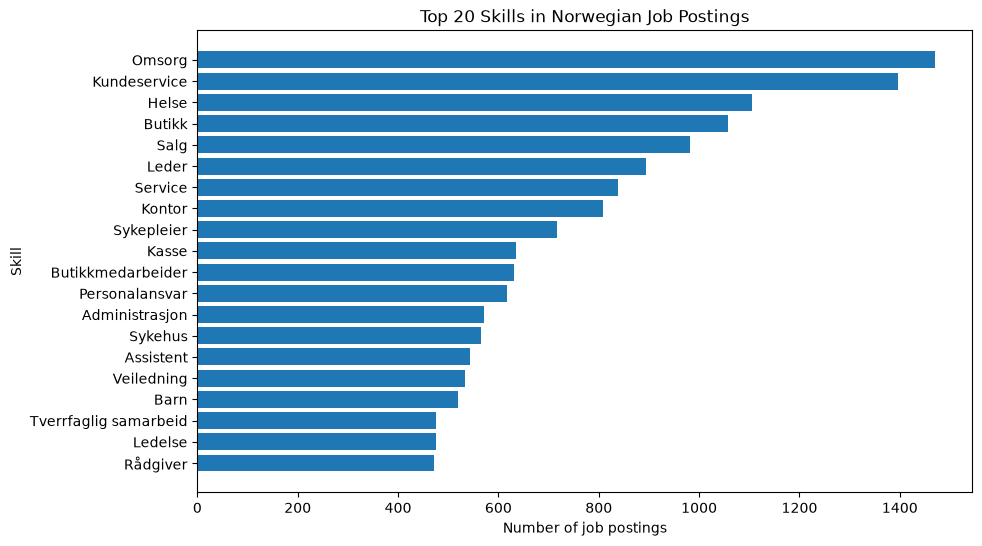

In [33]:
# Create a visualization of these top 20 skills.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_skills["skill"],
    top_skills["job_count"]
)

plt.xlabel("Number of job postings")
plt.ylabel("Skill")
plt.title("Top 20 Skills in Norwegian Job Postings")

plt.gca().invert_yaxis()

plt.show()

Finding:
The Norwegian job market sample is dominated by healthcare, service, retail, and management-related skills. These represent current labor demand, but frequency alone does not indicate future importance. Further analysis is needed to identify digital, AI, and emerging skills.

How many job postings require each number of skills?


Number of skills per job

In [34]:
job_skill_count = (
    skills_df
    .groupby("job_id")
    .size()
    .reset_index(name="number_of_skills")
)

job_skill_count.head()

,job_id,number_of_skills
0,0008dd66-d1c7-41ae-a911-1d6d0b84e092,10
1,001773d0-923c-4001-bea7-bb53098f5ba6,8
2,001903b6-c738-42b0-b70c-a9d13d1cbc85,10
3,001e12b0-b264-4fc6-9bb7-c9b42ff6dcf4,6
4,0028b108-259b-4554-8439-55bdc19f374e,10


In [35]:
job_skill_count.shape

(10000, 2)

In [36]:
job_skill_count["number_of_skills"].describe()

count    10000.000000
mean         9.532400
std          0.806979
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         13.000000
Name: number_of_skills, dtype: float64

Most Norwegian job postings contain around 9–10 listed skills. The skill extraction appears consistent because almost all jobs have multiple associated skills.

skills_df = exploded skill-level dataset: 95324 rows, one row = one (job_id, skill) pair

job_skill_count = number of skills per job: we have 10000 jobs, avg skill per job = 9.53.

which jobs have unusually few skills?

In [37]:
job_skill_count.sort_values(
    "number_of_skills"
).head(20)

,job_id,number_of_skills
1603,2961d69c-1023-44f7-8ead-103517f78ec7,1
6412,a33cf922-6b21-4ec8-b7e9-8a681678cfb3,1
6976,b114e7c5-659e-4f0f-8d86-249ee35a7882,1
8635,dd5c41ec-7d7b-402a-8c9e-6ab0a8a49f5c,1
8452,d88def75-e316-4a56-891a-8efa867feb24,1
5925,9759085b-d0a0-4896-b519-50df4d3aee97,1
8562,db647d74-6ec7-42d0-a9aa-7562f9648fcc,1
8257,d35cd6df-dd47-4dce-8f4c-8efcc362879a,1
4537,746bb7e7-290d-4fb3-957d-8a2df09c5578,1
8988,e60ccf80-7b0d-420e-adfd-f04cbabe91c4,1


Only a small number of jobs have very few skills.
Most jobs have around 9–10 skills
A few jobs have only 1 skill
This is not a problem; it is normal in the source data because some employers provide fewer structured skills

summary visualization

In [38]:
skill_count_distribution = (
    job_skill_count["number_of_skills"]
    .value_counts()
    .sort_index()
)

skill_count_distribution

number_of_skills
1       14
4        1
5       11
6       14
7       76
8     1054
9     2110
10    6709
11      10
13       1
Name: count, dtype: int64

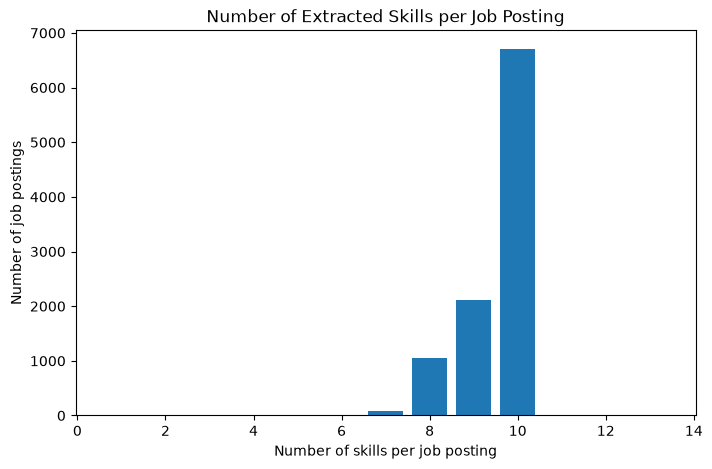

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    skill_count_distribution.index,
    skill_count_distribution.values
)

plt.xlabel("Number of skills per job posting")
plt.ylabel("Number of job postings")
plt.title("Number of Extracted Skills per Job Posting")

plt.show()

The important findings:

- 67% of job postings have exactly 10 skills (6709 / 10000)
- Most jobs have 8–10 skills
- Very few jobs have unusually low/high skill counts
- No data quality issue detected

The chart also confirms this distribution.

Skill coverage per job
- Create job_skill_count
- Show descriptive statistics
- Show distribution plot
- Brief interpretation

## Skill concentration / diversity
Are job postings dominated by a few common skills, or is the demand spread across many skills?

First, calculate how many unique skills we have (we already checked ~10,997), but now we analyze the distribution.

In [40]:
skills_df["skill"].value_counts().describe()

count    10997.000000
mean         8.668182
std         43.626013
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       1471.000000
Name: count, dtype: float64

In [41]:
skills_df["skill"].value_counts().head(50)

skill
Omsorg                   1471
Kundeservice             1396
Helse                    1106
Butikk                   1057
Salg                      981
Leder                     895
Service                   839
Kontor                    808
Sykepleier                716
Kasse                     636
Butikkmedarbeider         632
Personalansvar            618
Administrasjon            571
Sykehus                   565
Assistent                 543
Veiledning                533
Barn                      519
Tverrfaglig samarbeid     476
Ledelse                   475
Rådgiver                  472
Vedlikehold               471
Teamarbeid                470
Barnehage                 469
Prosjektledelse           446
Helsefagarbeider          441
Industri                  433
Pleie                     411
HMS                       402
Kundebehandling           402
Renhold                   382
Pasientbehandling         381
Bygg                      377
Vernepleier               368
Anal

Findings

- Unique skills:

- 10,997 different skills

Interpretation:

- The skill ecosystem is highly diverse
- Many skills appear only once or a few times
- A small group of common skills dominates the labor market

This is a typical long-tail distribution:

- few very common skills
- many rare skills


- common skills represent broad labor market needs
- rare skills may represent specialized roles or emerging areas

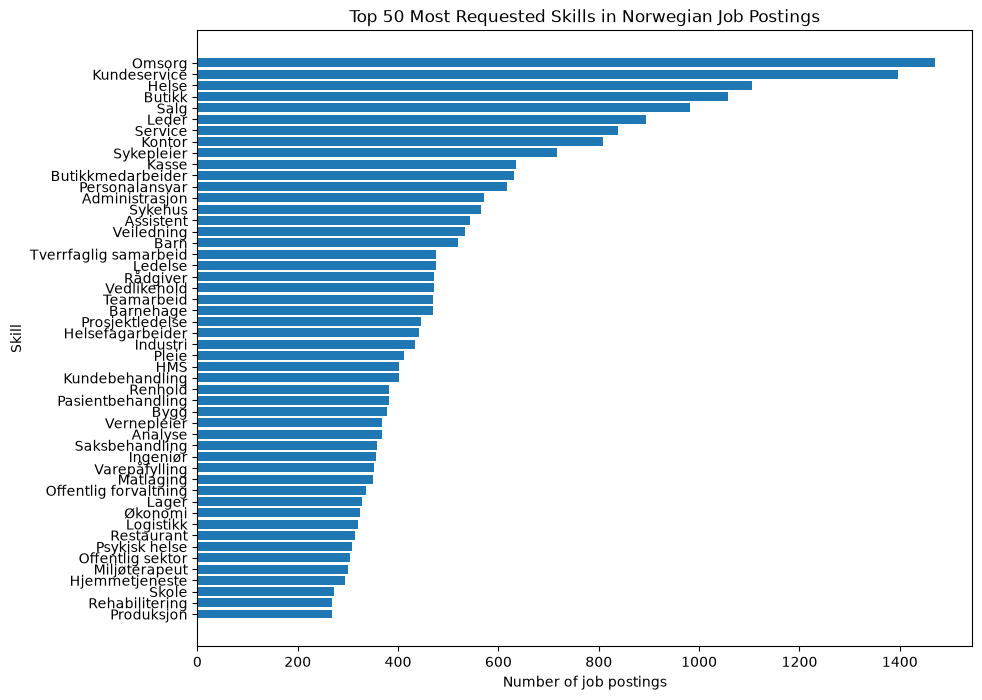

In [42]:
skill_frequency = skills_df["skill"].value_counts()

top_50_skills = skill_frequency.head(50)

plt.figure(figsize=(10,8))

plt.barh(
    top_50_skills.index[::-1],
    top_50_skills.values[::-1]
)

plt.xlabel("Number of job postings")
plt.ylabel("Skill")
plt.title("Top 50 Most Requested Skills in Norwegian Job Postings")

plt.show()

This chart confirms the same pattern we saw before: the Norwegian job market has a small group of highly demanded skills and a very long tail of less frequent skills.

1. Demand is concentrated around broad workplace skills

The highest-frequency skills are:

Omsorg (Care) → 1471 job postings
Kundeservice (Customer service) → 1396
Helse (Healthcare) → 1106
Butikk (Retail) → 1057
Salg (Sales) → 981

These are not narrow technical skills; they represent large employment sectors in Norway.

Insight:
The current dataset shows strong demand in:

healthcare and care services
customer-facing roles
retail and sales
general operational roles
2. Healthcare is a dominant theme

Several healthcare-related skills appear high in the ranking:

Helse
Sykepleier
Sykehus
Helsefagarbeider
Pleie
Pasientbehandling
Psykisk helse
Rehabilitering

This suggests healthcare is one of the strongest employment areas in this sample.

3. Many skills are soft skills / organizational skills

High-ranking examples:

Leder (Leader)
Personalansvar (Personnel responsibility)
Ledelse (Leadership)
Teamarbeid (Teamwork)
Tverrfaglig samarbeid (Cross-disciplinary collaboration)
Veiledning (Guidance)

This indicates employers frequently request interpersonal and management abilities, not only technical expertise.

4. Technical/digital skills are not visible in the top positions

From the top 50 list, we see some:

Analyse
Ingeniør
Økonomi
Logistikk
Produksjon

But classic AI/data/digital skills are not among the highest-frequency skills.

Important interpretation:

This does not mean digital skills are unimportant.

Possible reasons:

digital skills are distributed across many different names
they may appear in specific occupations rather than the whole market
this dataset includes many healthcare, retail, and service jobs

Later, this is exactly where the AI/future skills analysis notebook becomes useful.

5. The chart has a strong long-tail pattern

The difference between:

Omsorg: ~1471 postings
Lower top-50 skills: ~250-300 postings

shows that even within the top 50, demand drops significantly.

The full dataset is even more extreme:

10,997 unique skills
many skills appear only once

Skill demand by job context

How is AI changing the Norwegian labor market, and what skills will matter in the future?

we need relationships:

- Which skills appear in which occupations?
- Which skills appear in which job categories?
- Which cities demand which skills?

Step: Connect skills back to jobs

Merge skills_df with jobs_clean

Then we can answer:

- "What skills are demanded in healthcare?"
- "What skills are demanded in engineering?"
- "Where do digital skills appear?"

Skill demand by job category

What skills are important in different parts of the labor market?

In [ ]:
# merged dataset

skills_jobs_df = skills_df.merge(
    jobs_df[["job_id", "city", "category", "occupation", "title"]],
    on="job_id",
    how="left"
)

skills_jobs_df.head()

,job_id,skills,skill,city,category,occupation,title
0,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Arkiv,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
1,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Brukerstøtte,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
2,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Digitalisering,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
3,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Dokumentasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...
4,0112ac82-d16e-449b-8ae0-17e5bb874829,"Arkiv, Brukerstøtte, Digitalisering, Dokumenta...",Informasjonsforvaltning,LØRENSKOG,Not classified,Not classified,Vil du være med å styrke vår informasjonsforva...


obs_df → job-level data
skills_df → skill-level data
skills_jobs_df → combined analysis dataset

category = Not classified
occupation = Not classified

In [46]:
skills_jobs_df["category"].value_counts().head(20)

category
Sykepleier, Sykepleier, Sykepleiere                                                            2219
Butikkmedarbeider, Butikkmedarbeider, Butikkmedarbeidere                                       1991
Helsefagarbeider, Helsefagarbeider, Helsefagarbeidere                                          1580
Brukerstyrt personlig assistent (BPA), Brukerstyrt personlig assistent (BPA), Hjemmehjelper    1434
Butikkmedarbeider dagligvarebutikk, Butikkmedarbeider dagligvarebutikk, Butikkmedarbeidere      804
Sykepleier, Sykepleiere, Vernepleiere, Vernepleier, personlig assistent                         703
Butikkmedarbeidere, Butikkmedarbeider, butikkmedarbeider                                        691
Miljøterapeut, Miljøterapeut, Miljøarbeidere innen sosiale fagfelt                              686
Prosjektleder, Prosjektleder, Andre administrative ledere                                       607
Avdelingsleder, Avdelingsleder, Andre ledere av produksjon og tjenesteyting                

1. Category is too detailed and duplicated

It contains multiple related labels in one string, not a single category.

2. It overlaps with occupation

This confirms our earlier finding:

occupation → incomplete
category → messy but contains useful occupation-like information
Decision for this project

Do not use category directly for analysis.

In [47]:
skills_jobs_df["city"].value_counts().head(20)

city
OSLO                17855
TRONDHEIM            4012
BERGEN               3941
Missing location     3541
STAVANGER            2732
BODØ                 2069
TROMSØ               1928
KONGSBERG            1374
SANDNES              1332
ÅLESUND              1312
KRISTIANSAND S       1229
DRAMMEN              1126
HAUGESUND             945
LØRENSKOG             829
SKIEN                 773
TØNSBERG              763
LILLEHAMMER           739
ASKER                 713
ALTA                  617
MOLDE                 604
Name: count, dtype: int64

1. Job demand is geographically concentrated

Top cities:

Oslo → 17,855 skill records
Trondheim → 4,012
Bergen → 3,941
Stavanger → 2,732
Bodø → 2,069
Tromsø → 1,928

Oslo is significantly larger than other cities, which is expected because it is Norway's largest labor market.

2. Missing location exists
Missing location → 3541

This is a notable data quality point.

We already handled missing cities in 01_data_quality_eda, so here we simply keep it as a category.

No need to remove it.

3. City is useful for later analysis

Unlike category and occupation, city is cleaner.

Later we can answer:

Which skills are demanded in Oslo vs other regions?
Are digital skills concentrated in certain cities?
Do different regions have different skill profiles?

## Skill demand by city
we will analyze top skills by city (not overall). This will use the dataset we just created.

Are different regions in Norway demanding different skills?

In [48]:
city_skill_frequency = (
    skills_jobs_df
    .groupby(["city", "skill"])
    .size()
    .reset_index(name="job_count")
)

city_skill_frequency.head()

,city,skill,job_count
0,AKLAND,Anleggsleder,1
1,AKLAND,Arbeidsmiljø,1
2,AKLAND,Betongarbeider,1
3,AKLAND,Bygg,1
4,AKLAND,Byggeplass,1


In [49]:
oslo_skills = (
    city_skill_frequency[
        city_skill_frequency["city"] == "OSLO"
    ]
    .sort_values("job_count", ascending=False)
)

oslo_skills.head(20)

,city,skill,job_count
33334,OSLO,Kontor,269
33448,OSLO,Kundeservice,187
31586,OSLO,Analyse,168
33552,OSLO,Leder,162
34559,OSLO,Salg,152
31990,OSLO,Butikk,147
33966,OSLO,Omsorg,142
34530,OSLO,Rådgiver,136
31519,OSLO,Administrasjon,123
33949,OSLO,Offentlig sektor,120


Oslo skill demand findings

Compared with the national top skills, Oslo has a different profile.

1. Administrative and knowledge-work skills are more visible

Oslo top skills include:

Kontor (Office) → 269
Analyse (Analysis) → 168
Rådgiver (Advisor) → 136
Administrasjon → 123
Offentlig sektor → 120
Prosjektledelse → 106
Økonomi → 92
Strategi → 89

This suggests Oslo has a stronger presence of:

administrative roles
consulting/advisory roles
analytical work
management/project work
2. Digital-related skills appear higher

Important:

Digitalisering → 87

It was not visible in the overall top 20 skills, but it appears in Oslo's top 20.

This is an interesting signal for later AI/future skills analysis:

digital skills may be geographically concentrated
large cities may have stronger demand for digital transformation roles
3. Healthcare and service are still important

Oslo also contains:

Omsorg → 142
Sykehus → 106
Kundeservice → 187
Service → 113

So Oslo is not only technology/office work; it has a mixed labor market.

Step: Calculate skill share within each city

What percentage of a city's skill demand comes from each skill?

In [50]:
city_skill_share = city_skill_frequency.copy()

city_totals = (
    city_skill_share
    .groupby("city")["job_count"]
    .sum()
    .reset_index(name="city_total_skills")
)

city_skill_share = city_skill_share.merge(
    city_totals,
    on="city"
)

city_skill_share["skill_share"] = (
    city_skill_share["job_count"] /
    city_skill_share["city_total_skills"]
)

In [51]:
oslo_skill_share = (
    city_skill_share[
        city_skill_share["city"] == "OSLO"
    ]
    .sort_values("skill_share", ascending=False)
)

oslo_skill_share.head(20)

,city,skill,job_count,city_total_skills,skill_share
33334,OSLO,Kontor,269,17855,0.015066
33448,OSLO,Kundeservice,187,17855,0.010473
31586,OSLO,Analyse,168,17855,0.009409
33552,OSLO,Leder,162,17855,0.009073
34559,OSLO,Salg,152,17855,0.008513
31990,OSLO,Butikk,147,17855,0.008233
33966,OSLO,Omsorg,142,17855,0.007953
34530,OSLO,Rådgiver,136,17855,0.007617
31519,OSLO,Administrasjon,123,17855,0.006889
33949,OSLO,Offentlig sektor,120,17855,0.006721


Interpretation:
Oslo's profile is different from the national picture

National top skills:

Omsorg
Kundeservice
Helse
Butikk
Salg

Oslo relative demand shows more:

Kontor
Analyse
Rådgiver
Administrasjon
Prosjektledelse
Digitalisering

This suggests Oslo has a stronger concentration of:

administrative work
knowledge work
analytical roles
digital transformation activities
Digitalization signal appears

Digitalisering is not among the highest national skills, but it appears in Oslo's top skills.

This is useful later for 03_ai_future_skills.

Why we needed normalization

Before:

Oslo has many Kontor jobs because Oslo is large.

After:

Kontor represents a relatively important part of Oslo's skill demand.

This makes city comparisons more meaningful.

Step 1 — Complete city comparison (last analytical part)

In [52]:
top_cities = [
    "OSLO",
    "BERGEN",
    "TRONDHEIM",
    "STAVANGER"
]

city_comparison = (
    city_skill_share[
        city_skill_share["city"].isin(top_cities)
    ]
    .sort_values(
        ["city", "skill_share"],
        ascending=[True, False]
    )
)

city_comparison.head()

,city,skill,job_count,city_total_skills,skill_share
3142,BERGEN,Kontor,43,3941,0.010911
3188,BERGEN,Kundeservice,43,3941,0.010911
3650,BERGEN,Salg,39,3941,0.009896
3219,BERGEN,Leder,34,3941,0.008627
3631,BERGEN,Rådgiver,33,3941,0.008374


Interpretation:

Compared with Oslo:

Similarities

Kontor, Kundeservice, Salg, Leder, Rådgiver appear in both.
Large Norwegian cities share many labor market needs.

Difference

Oslo showed stronger signals in:
Analyse
Administrasjon
Strategi
Digitalisering
Bergen's profile appears more balanced around:
service
sales
leadership
advisory roles

This suggests city differences exist, but they are not completely different labor markets.

In [53]:
top_city_skills = (
    city_comparison
    .groupby("city")
    .head(10)
)

top_city_skills

,city,skill,job_count,city_total_skills,skill_share
3142,BERGEN,Kontor,43,3941,0.010911
3188,BERGEN,Kundeservice,43,3941,0.010911
3650,BERGEN,Salg,39,3941,0.009896
3219,BERGEN,Leder,34,3941,0.008627
3631,BERGEN,Rådgiver,33,3941,0.008374
3383,BERGEN,Omsorg,32,3941,0.008120
3537,BERGEN,Prosjektledelse,32,3941,0.008120
2471,BERGEN,Administrasjon,31,3941,0.007866
2957,BERGEN,Helse,30,3941,0.007612
2654,BERGEN,Bygg,27,3941,0.006851


Interpretation of city comparison

We compared the normalized skill demand for:

Oslo
Bergen
Stavanger
Trondheim

The main finding:

1. Large cities share many common skills

Across cities, recurring skills are:

Kontor
Kundeservice
Salg
Leder
Rådgiver
Helse
Omsorg

This suggests a common Norwegian labor market structure.

2. Cities have different skill profiles

Oslo

More knowledge/administrative signals:
Analyse
Administrasjon
Strategi
Digitalisering
Offentlig sektor

Bergen

More balanced profile:
Service
Sales
Administration
Healthcare
Construction

Stavanger

Stronger industry signal:
Helse
Sykepleier
Olje og gass
Ingeniør
Prosjektledelse

Trondheim

Stronger advisory/knowledge profile:
Kontor
Rådgiver
Prosjektledelse
Helse


This analysis is worth keeping because it supports the main story:

Skills are not distributed equally across Norway. Different regions show different labor market profiles, which matters when identifying future skills and AI-related opportunities.

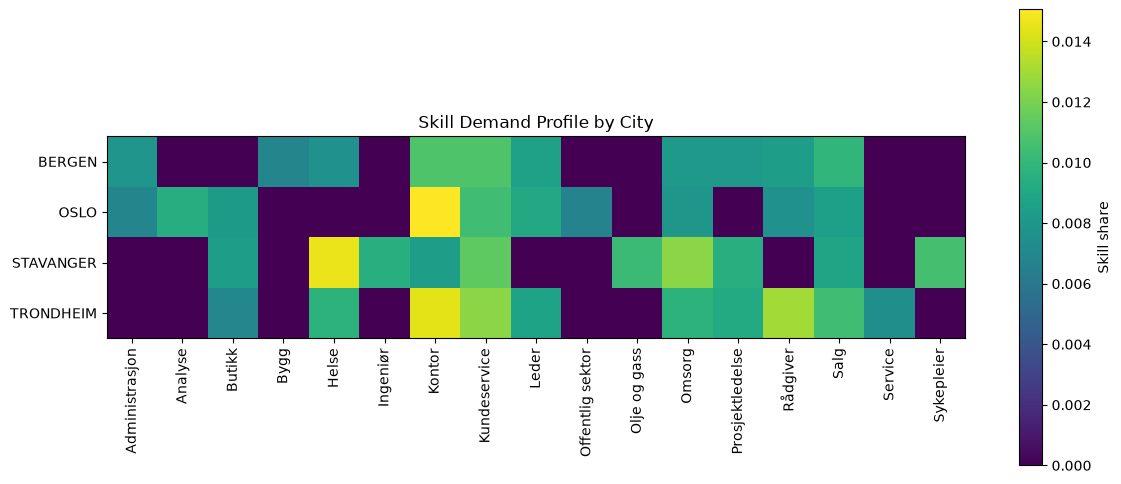

In [55]:
import matplotlib.pyplot as plt

city_heatmap = (
    top_city_skills
    .pivot(
        index="city",
        columns="skill",
        values="skill_share"
    )
    .fillna(0)
)

plt.figure(figsize=(12,5))

plt.imshow(city_heatmap)

plt.xticks(
    range(len(city_heatmap.columns)),
    city_heatmap.columns,
    rotation=90
)

plt.yticks(
    range(len(city_heatmap.index)),
    city_heatmap.index
)

plt.colorbar(label="Skill share")

plt.title("Skill Demand Profile by City")

plt.tight_layout()

plt.show()

Skill Demand Profile by City

The heatmap shows that skill demand differs between major Norwegian cities.

Key observations:

Oslo
Higher relative demand for:
Analyse
Administrasjon
Kontor
Offentlig sektor
Indicates a stronger knowledge, administrative, and advisory-oriented labor market.
Stavanger
Stronger presence of:
Olje og gass
Ingeniør
Sykepleier
Helse
Reflects the city's industrial and energy-related labor market.
Trondheim
Higher relative demand for:
Rådgiver
Kontor
Prosjektledelse
Shows a stronger professional/advisory profile.
Bergen
More balanced distribution:
Kundeservice
Kontor
Salg
Helse
Bygg
Conclusion:

Although Norwegian cities share many common skill demands, regional differences exist. Oslo has stronger demand for analytical and administrative skills, Stavanger shows stronger industry-related demand, and other cities have more balanced profiles across service, healthcare, and professional skills.

Step 2 — Save outputs

In [56]:
skills_jobs_df.to_csv(
    "../data/processed/skills_jobs_analysis.csv",
    index=False
)

skill_frequency.to_csv(
    "../data/processed/skill_frequency.csv",
    index=False
)

city_skill_share.to_csv(
    "../data/processed/city_skill_analysis.csv",
    index=False
)

In [57]:
import os

for file in [
    "../data/processed/skills_jobs_analysis.csv",
    "../data/processed/skill_frequency.csv",
    "../data/processed/city_skill_analysis.csv"
]:
    print(file, os.path.exists(file))

../data/processed/skills_jobs_analysis.csv True
../data/processed/skill_frequency.csv True
../data/processed/city_skill_analysis.csv True


## Summary of Skill Analysis

The Norwegian labor market shows strong demand for healthcare,
service, retail, and management-related skills.

Skill demand varies geographically. Oslo shows stronger demand
for analytical, administrative, advisory, and digitalization-related
skills compared with the national pattern.

The analysis provides the foundation for identifying digital and
AI-related future skills in the next stage.

## Conclusion

This analysis identified the current skill landscape of Norwegian job postings.
Demand is concentrated around healthcare, service, retail, and management skills,
while regional differences reveal different labor market profiles across cities.

The next analysis focuses on identifying digital and AI-related skills and their
role in the future Norwegian labor market.